# Fraud Detection - Exploratory Data Analysis

**About The Dataset**

The dataset contains transactions made by credit cards in September 2013 by European cardholders. This dataset presents transactions that occurred in two days, and is highly imbalanced, the positive class (frauds) account for 0.172% of all transactions.

Due to privacy and confidentiality issues, the original features are recoded to features `V1`, `V2`, … `V28` via PCA, and appear to be normalized. '`Time` and `Amount` remain un-transformed. `Time` contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature `Amount` is the transaction Amount. The target feature `Class` is the response variable and it takes value 1 in case of fraud and 0 otherwise.

**Provenance:**

The dataset was collected during a research collaboration between Worldline and Machine Learning Group (http://mlg.ulb.ac.be) of ULB (Université Libre de Bruxelles) on big data mining and fraud detection.

Cited works relevant to the initial research and data collection done by ULB are available at the end of this notebook.

## Imports and Config

**Imports**

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

spark = (
    SparkSession.builder
    .appName("Fraud Detection EDA")
    .getOrCreate()
)

seed = 42

## Data Loading and Initial Inspection

**Load Data**

In [2]:
data = spark.read.csv("fraud.csv",header=True,inferSchema=True)

#### Initial Inspection

In [3]:
data.printSchema()

root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: double (nullable = true)
 |-- V28: double (nulla

In [4]:
rows = data.count()
cols = len(data.columns)

print(f"Shape: ({rows}, {cols})")

Shape: (284807, 31)


In [5]:
data.show(5, truncate=False)

+----+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+------+-----+
|Time|V1                |V2                 |V3              |V4                |V5                 |V6                 |V7                 |V8                |V9                |V10                |V11               |V12               |V13               |V14               |V15               |V16               |V17               |V18                |V19               |V20                |V21                 |V22                |V23  

In [6]:
data.dtypes

[('Time', 'double'),
 ('V1', 'double'),
 ('V2', 'double'),
 ('V3', 'double'),
 ('V4', 'double'),
 ('V5', 'double'),
 ('V6', 'double'),
 ('V7', 'double'),
 ('V8', 'double'),
 ('V9', 'double'),
 ('V10', 'double'),
 ('V11', 'double'),
 ('V12', 'double'),
 ('V13', 'double'),
 ('V14', 'double'),
 ('V15', 'double'),
 ('V16', 'double'),
 ('V17', 'double'),
 ('V18', 'double'),
 ('V19', 'double'),
 ('V20', 'double'),
 ('V21', 'double'),
 ('V22', 'double'),
 ('V23', 'double'),
 ('V24', 'double'),
 ('V25', 'double'),
 ('V26', 'double'),
 ('V27', 'double'),
 ('V28', 'double'),
 ('Amount', 'double'),
 ('Class', 'int')]

In [7]:
data.describe().show()

+-------+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+--------------------+
|summary|              Time|                  V1|                  V2|                  V3|                  V4|                  V5|                  V6|                  V7|                  V8|                  V9|                 V10|                 V11|                 V12|                 V13|                 V14|                 V15|

## Data Quality

#### Unique Counts and Null Counts

Note: As observed below, the data contains no null feature values.

In [8]:
#Unique Counts
unique_counts = data.select([
    F.countDistinct(F.col(c)).alias(c)
    for c in data.columns
])

unique_counts.show()

+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+-----+
|  Time|    V1|    V2|    V3|    V4|    V5|    V6|    V7|    V8|    V9|   V10|   V11|   V12|   V13|   V14|   V15|   V16|   V17|   V18|   V19|   V20|   V21|   V22|   V23|   V24|   V25|   V26|   V27|   V28|Amount|Class|
+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+-----+
|124592|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663|275663| 32767|    2|
+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+-

In [9]:
#Null Counts
data.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in data.columns
]).show()

+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|Time| V1| V2| V3| V4| V5| V6| V7| V8| V9|V10|V11|V12|V13|V14|V15|V16|V17|V18|V19|V20|V21|V22|V23|V24|V25|V26|V27|V28|Amount|Class|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|   0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|     0|    0|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+



#### Duplicate Row Check

In [10]:
total_rows = data.count()
distinct_rows = data.distinct().count()
dupes = total_rows - distinct_rows
print(f"There are {dupes} duplicate rows in the data")

There are 1081 duplicate rows in the data


## Class Distribution

**Counts and Percentages**

In [11]:
total = data.count()
class_distribution = (
    data
    .groupBy("Class")
    .count()
    .withColumn(
        "percentage",
        F.col("count") / F.lit(total) * 100
    )
    .orderBy("Class")
)
class_distribution.show()

+-----+------+------------------+
|Class| count|        percentage|
+-----+------+------------------+
|    0|284315| 99.82725143693798|
|    1|   492|0.1727485630620034|
+-----+------+------------------+



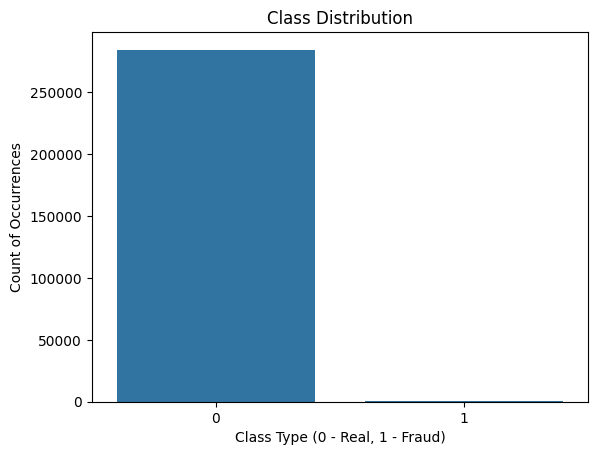

In [12]:
class_pd = class_distribution.toPandas()
sns.barplot(data=class_pd, x="Class", y="count")
plt.title("Class Distribution")
plt.xlabel("Class Type (0 - Real, 1 - Fraud)")
plt.ylabel("Count of Occurrences")
plt.show()

## Feature Distribution by Class

**Overlaid KDE Plots V1-V28, Time and Amount, Fraud vs Non-Fraud**

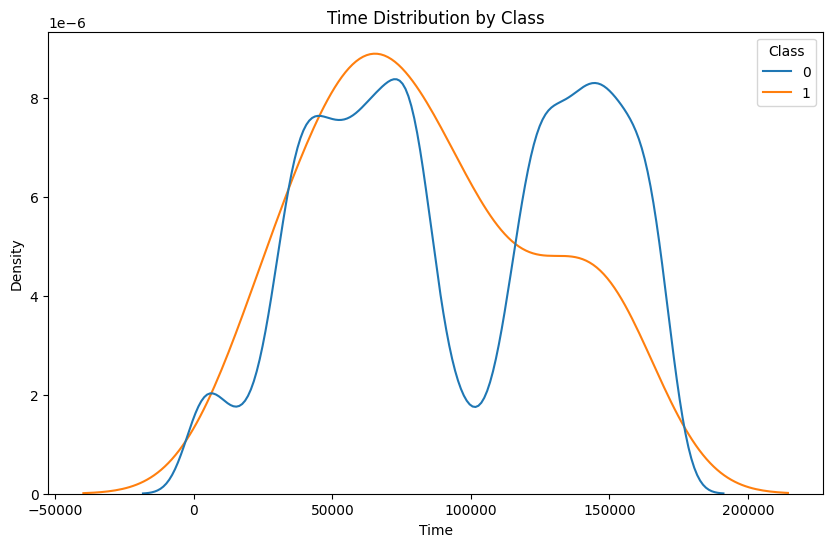

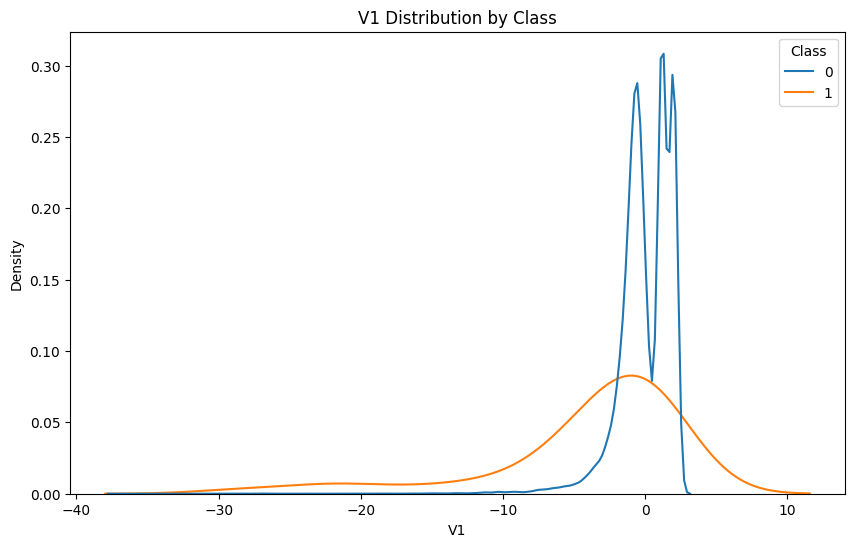

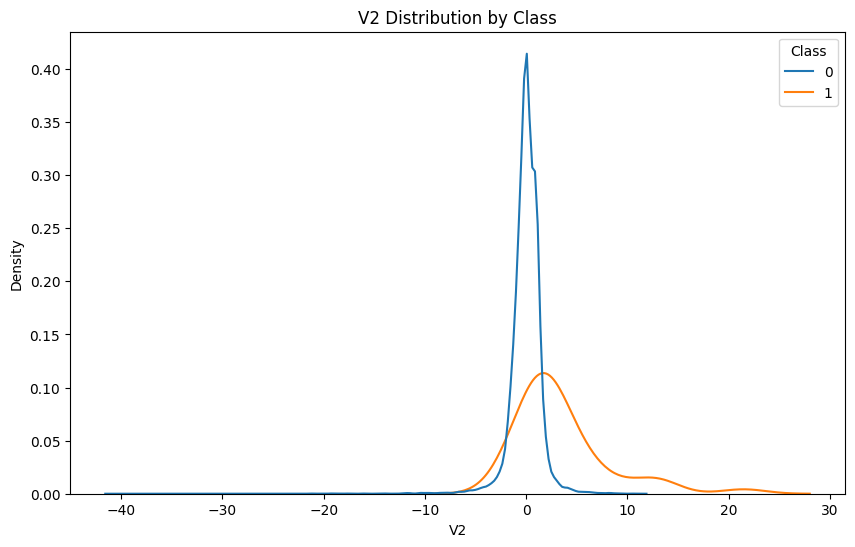

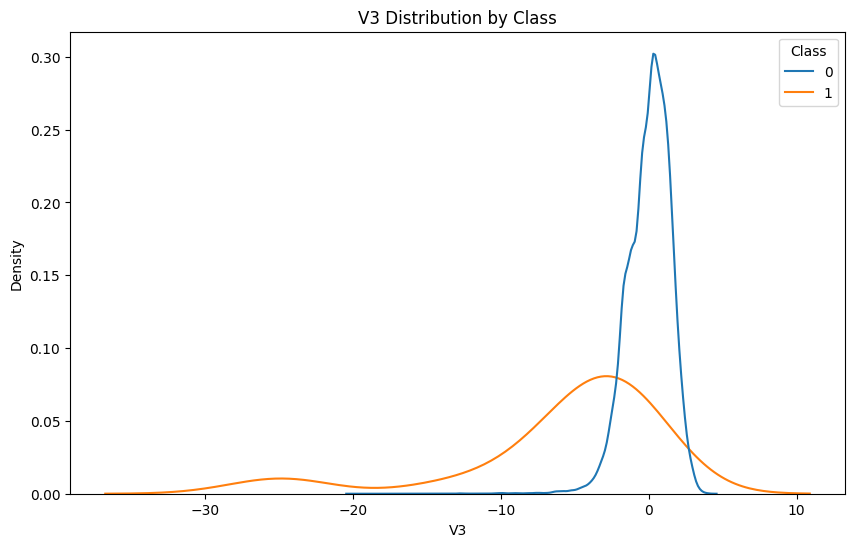

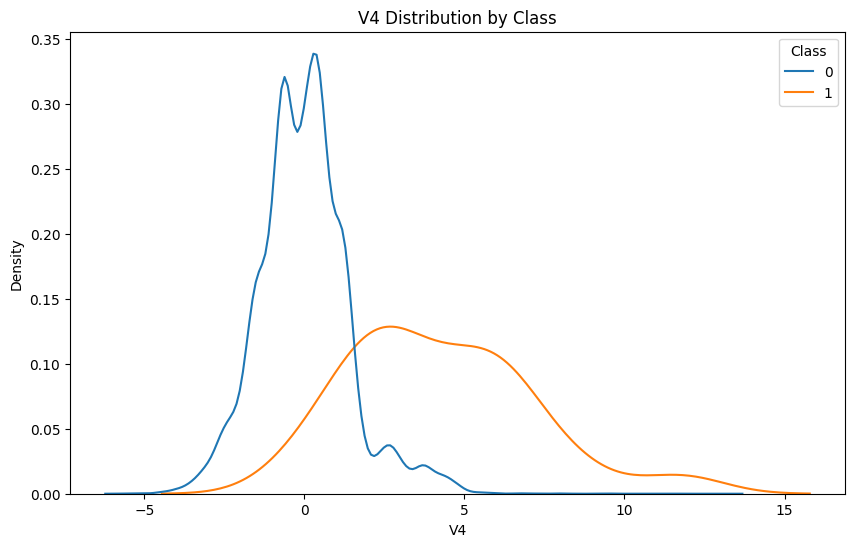

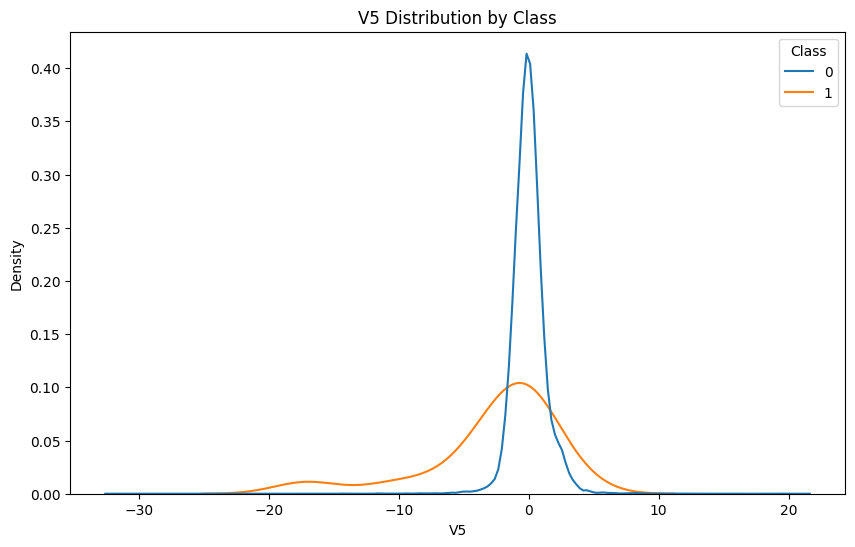

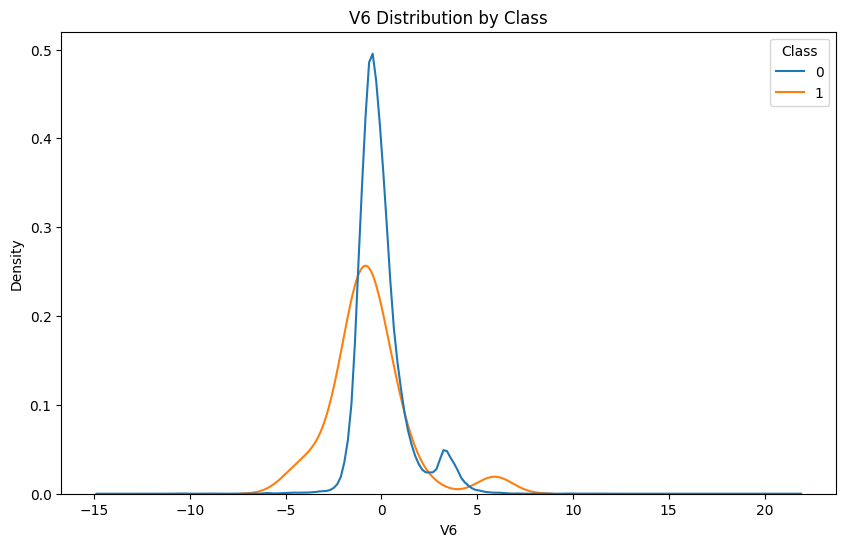

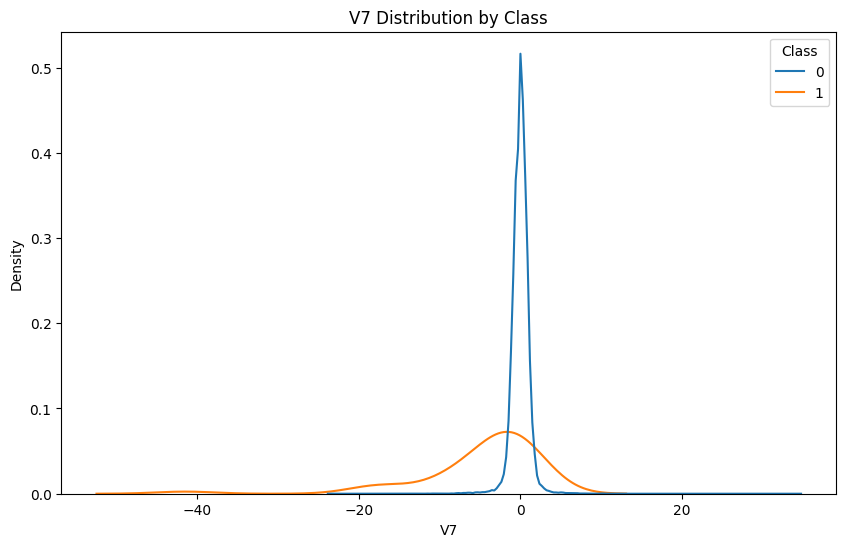

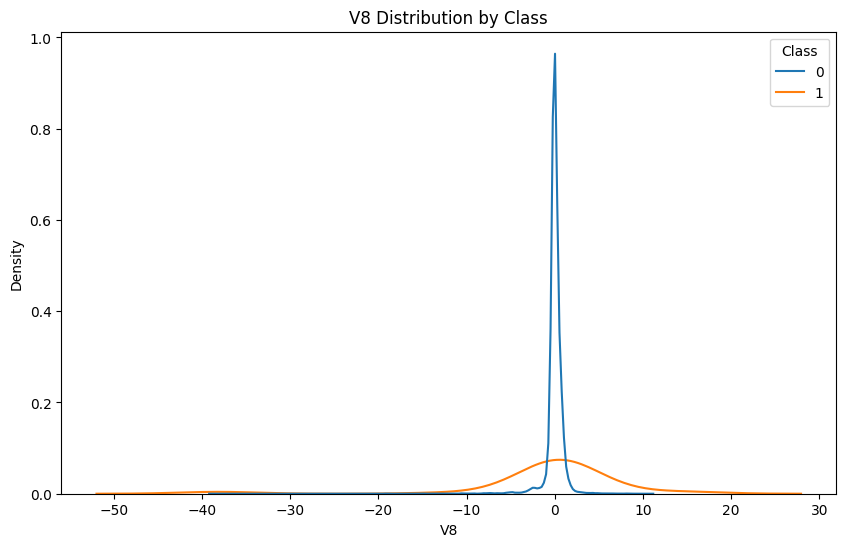

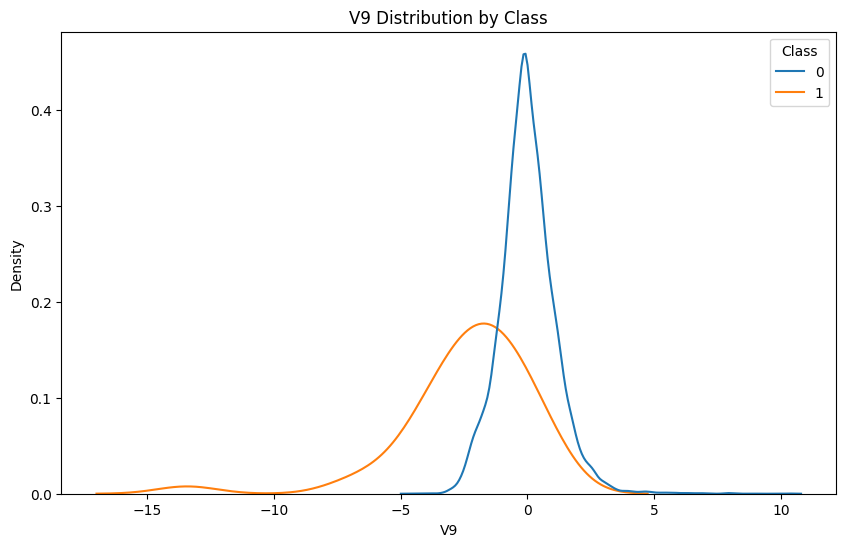

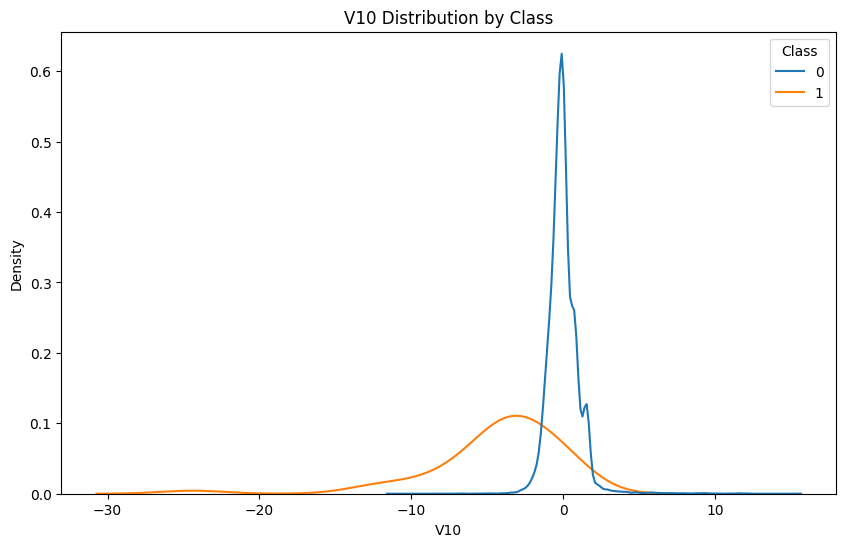

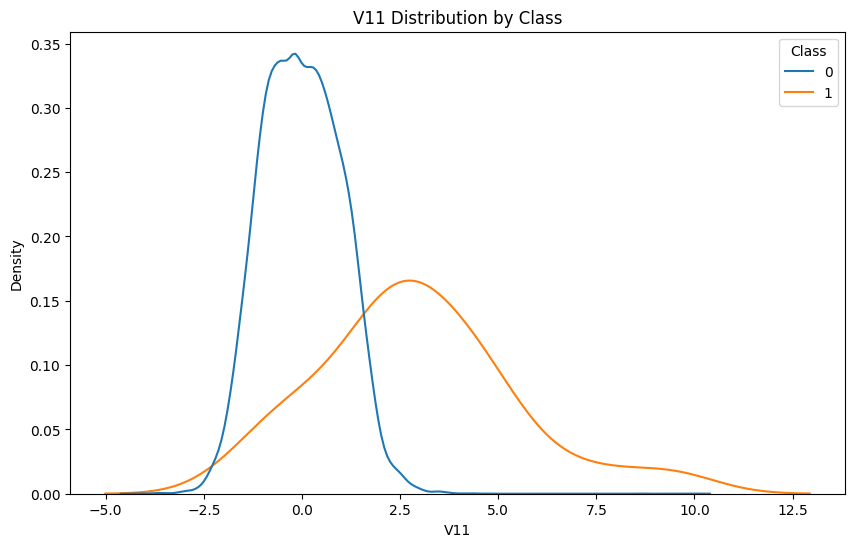

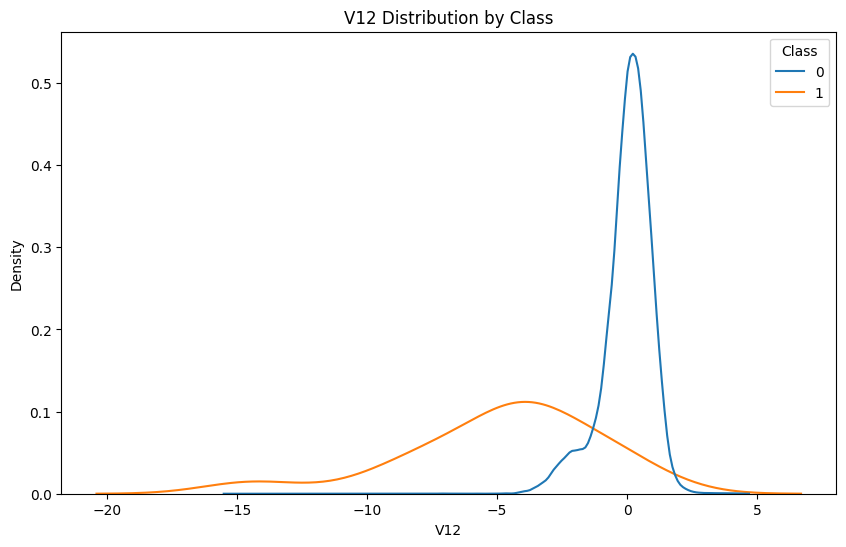

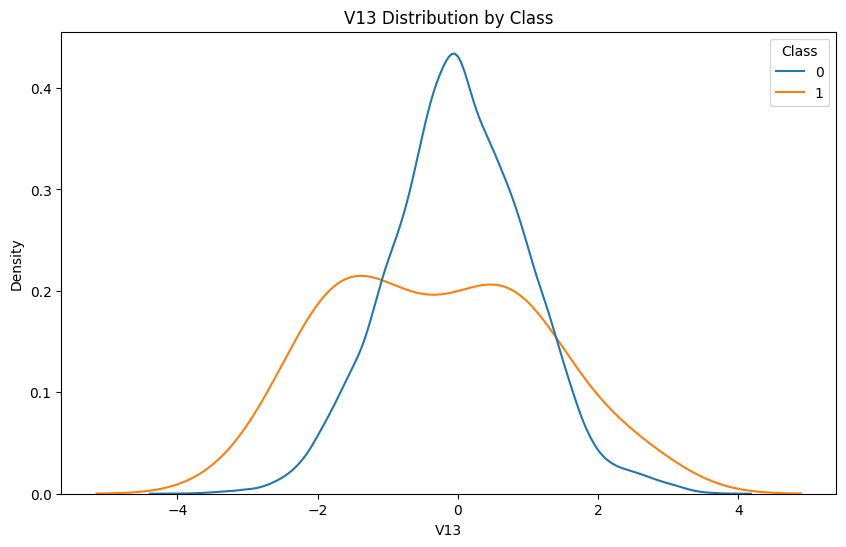

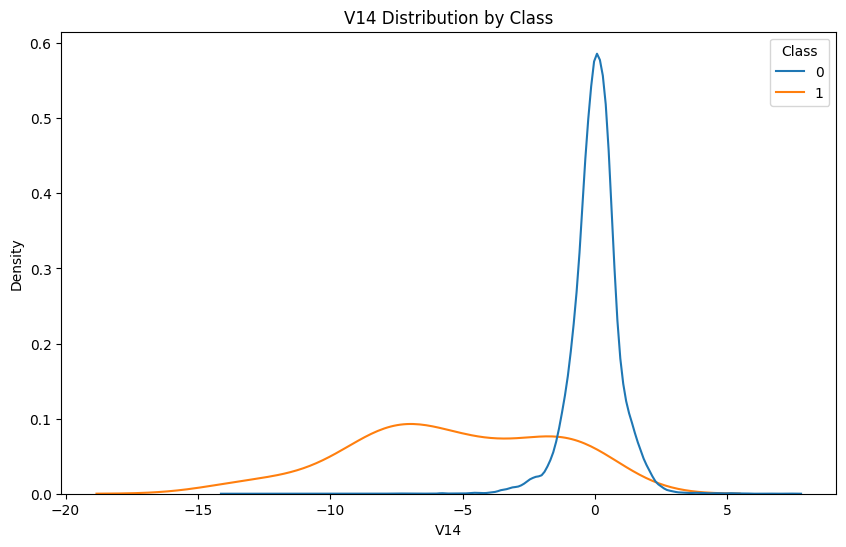

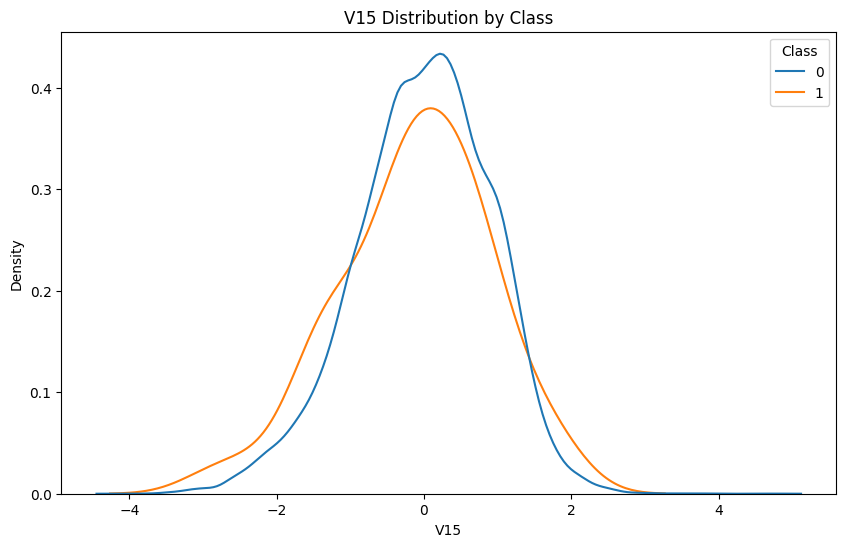

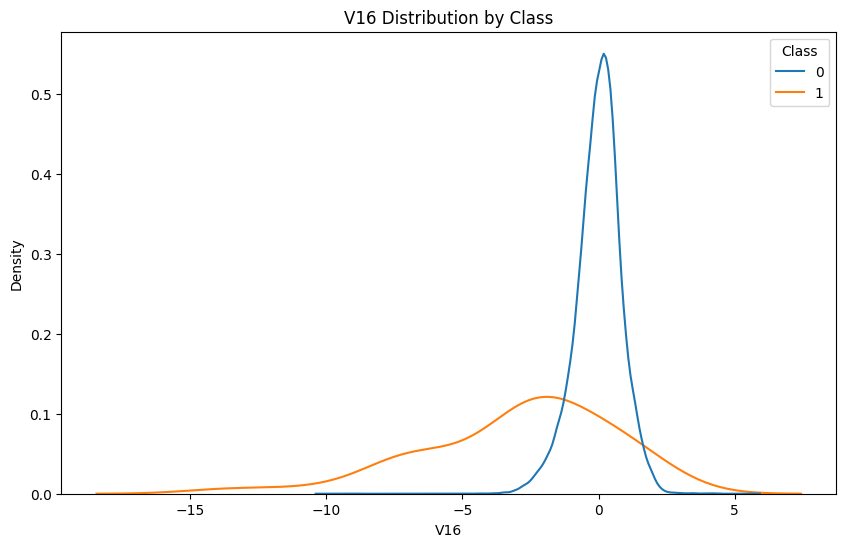

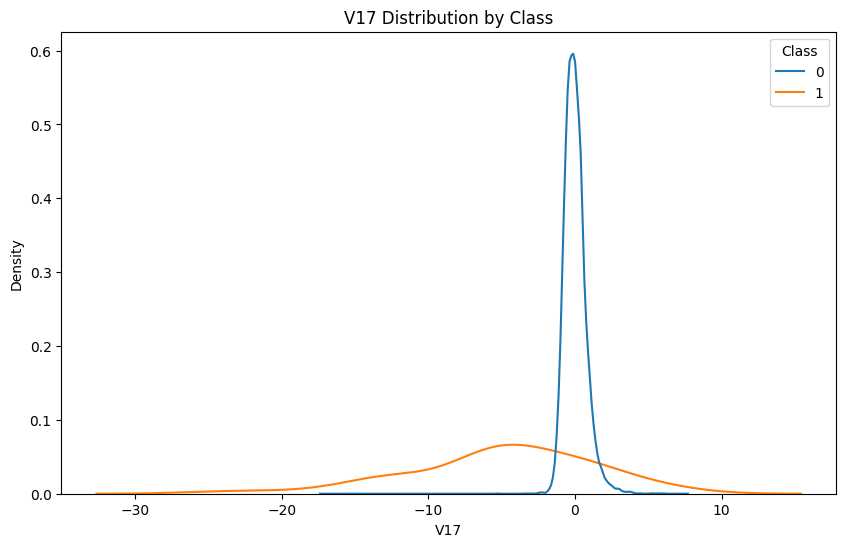

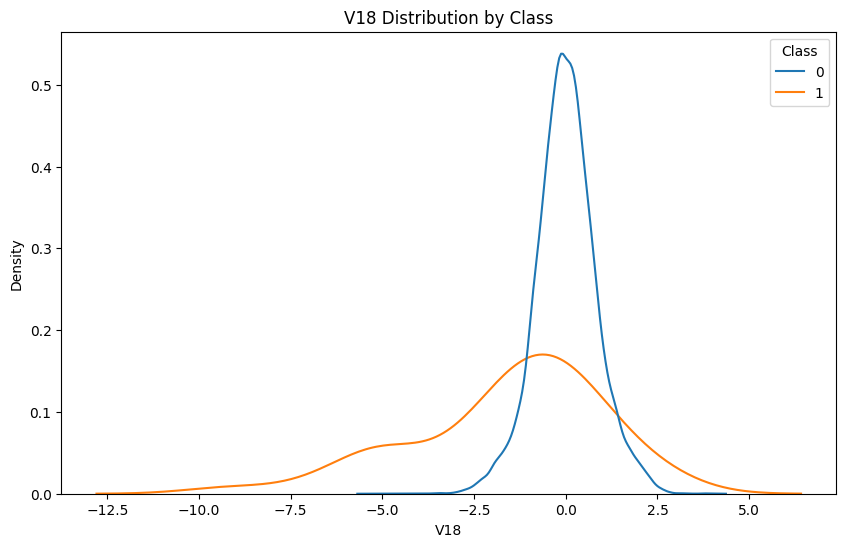

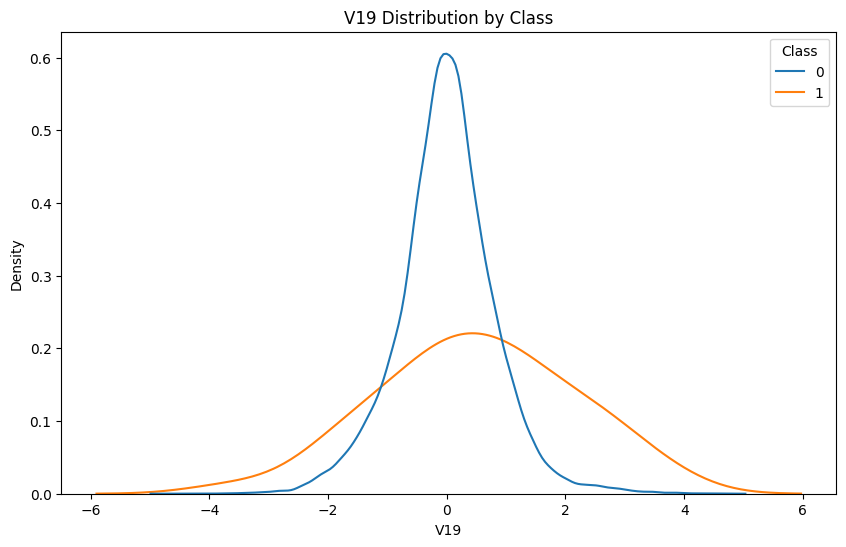

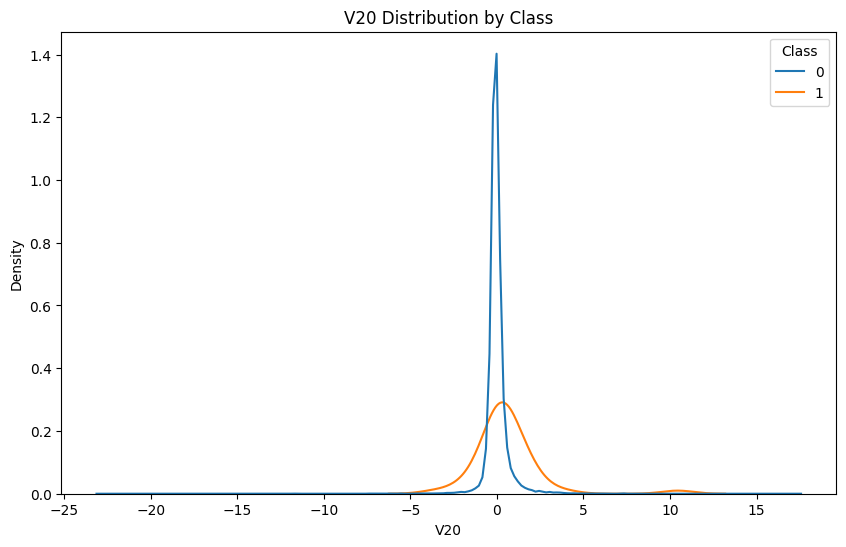

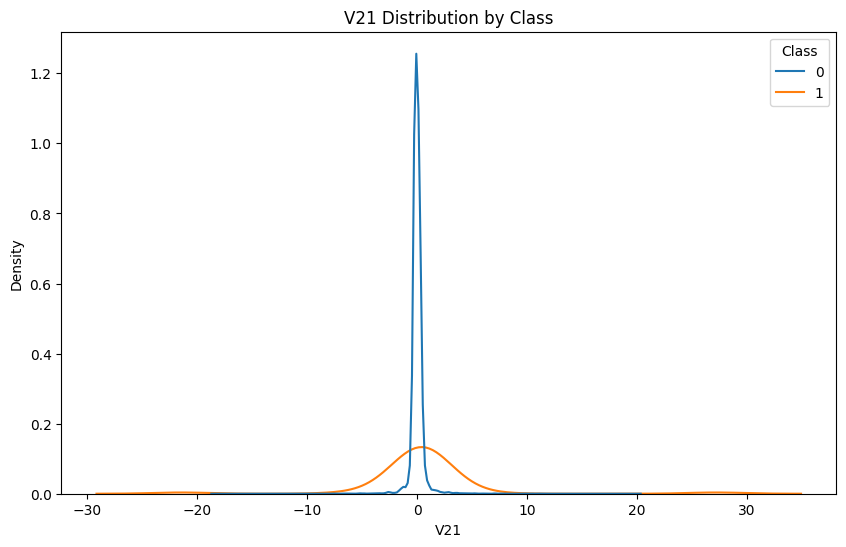

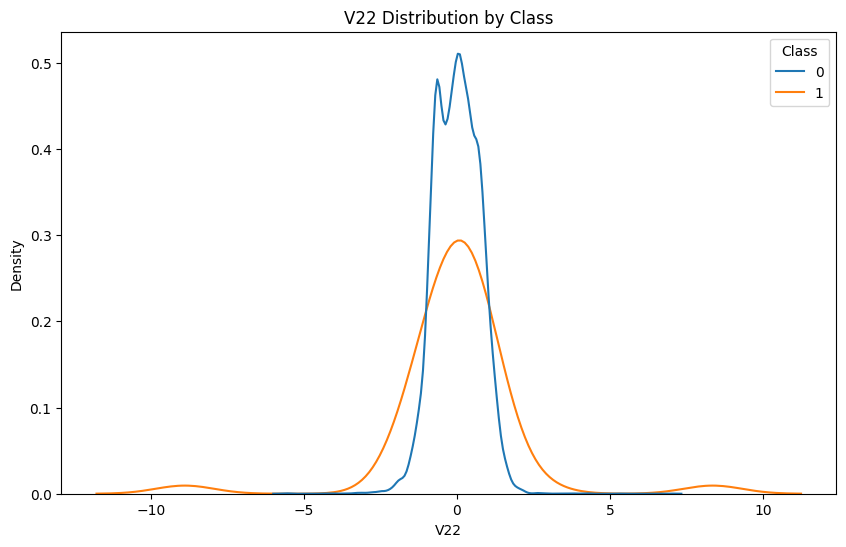

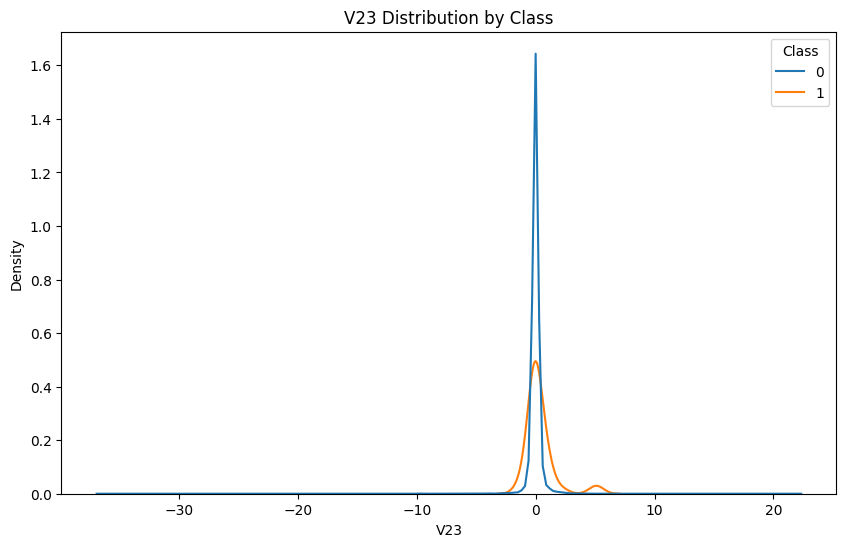

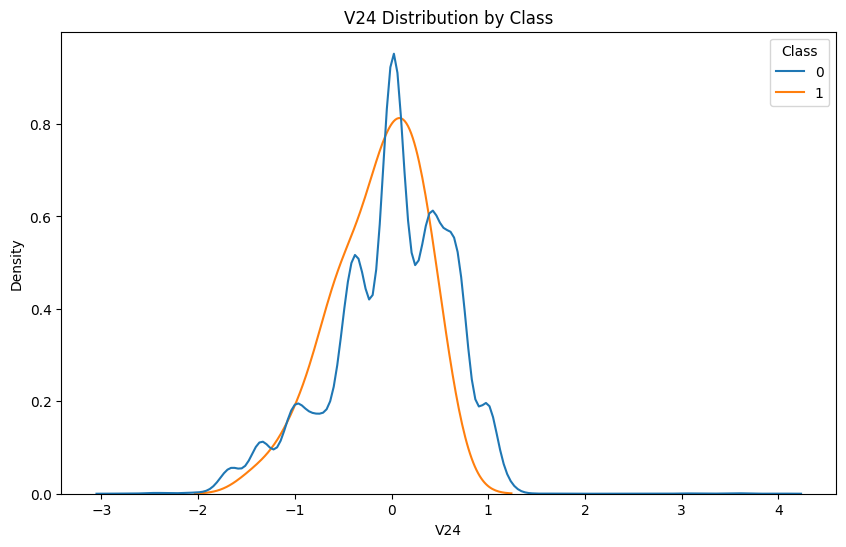

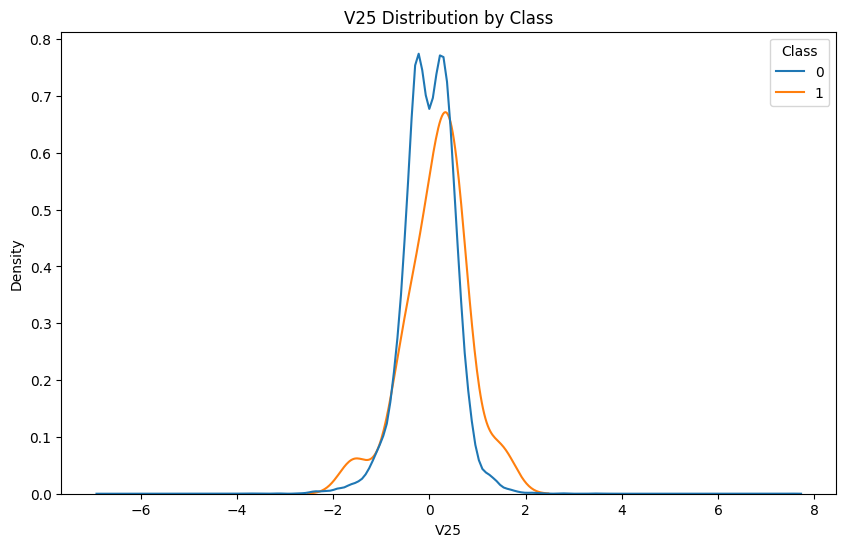

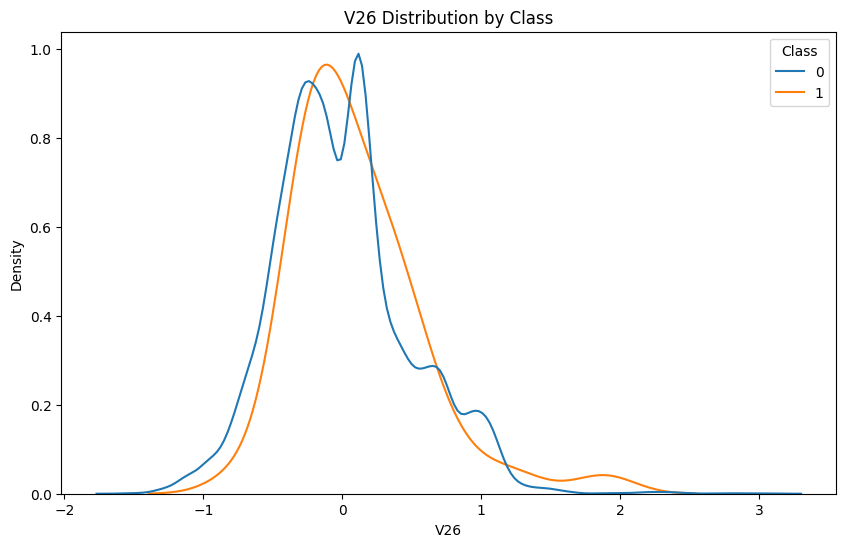

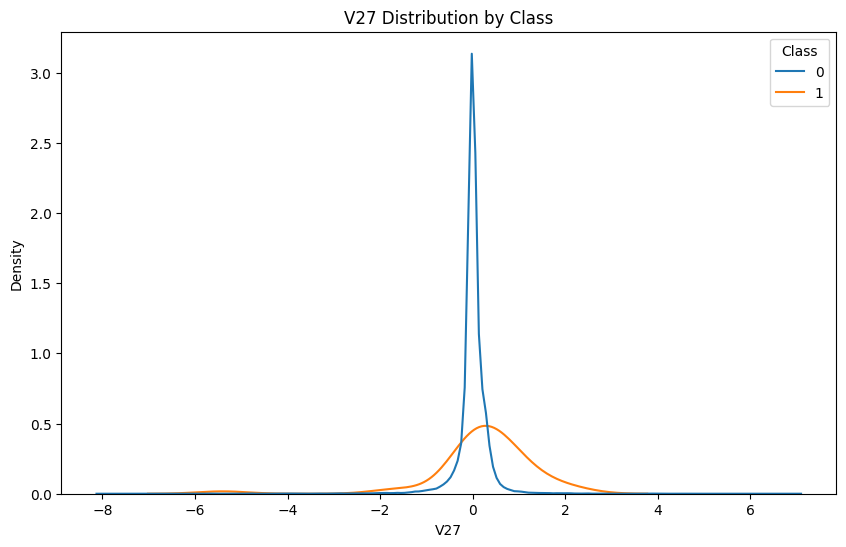

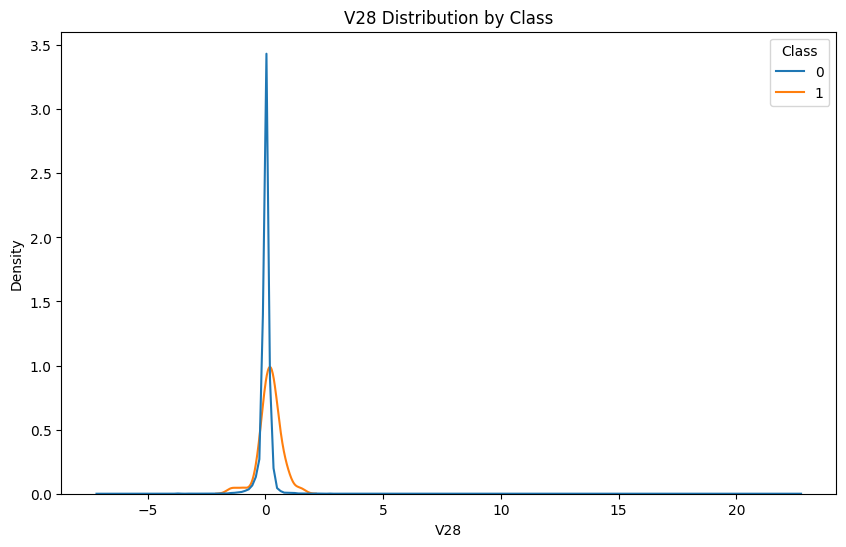

/tmp/ipykernel_2986/1038167695.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=sample_pd, x=feature, hue="Class", common_norm=False)


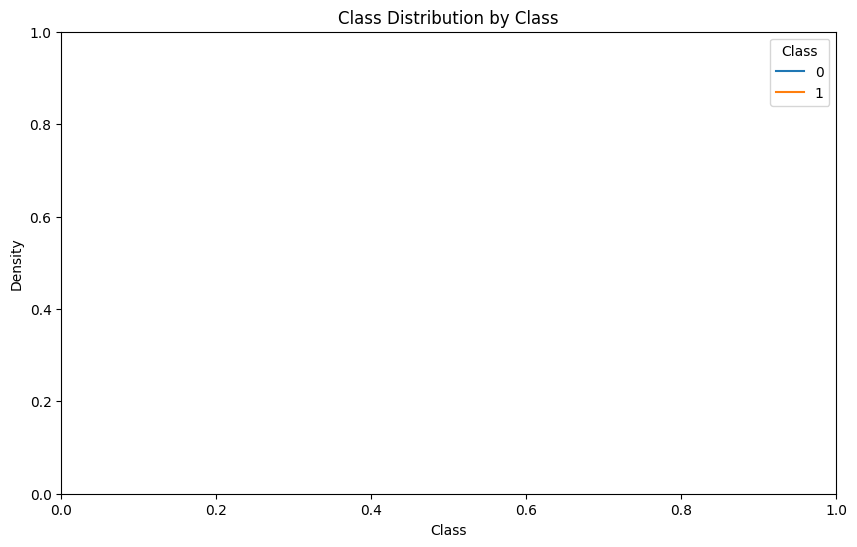

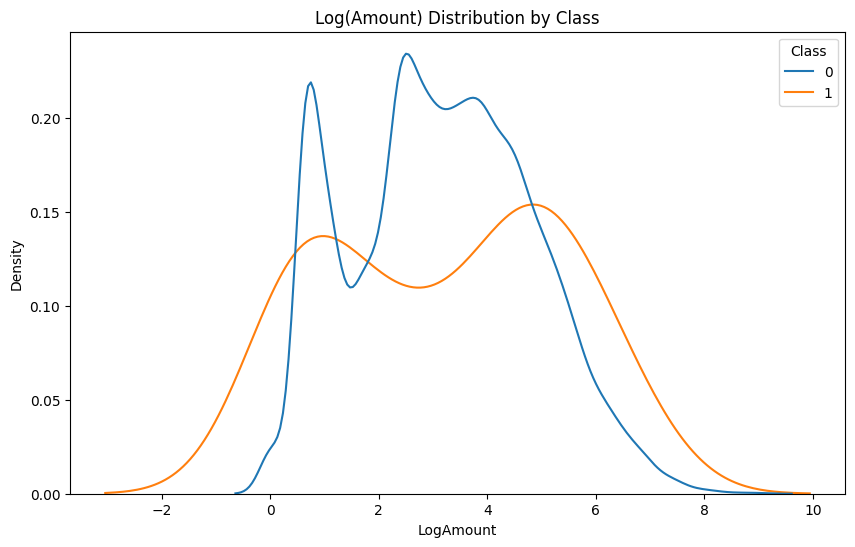

In [13]:
sample_pd = (data.sample(withReplacement=False, fraction=0.10, seed=seed).toPandas())
features = data.columns

for feature in features:
    if feature != "Amount":
        plt.figure(figsize=(10, 6))
        sns.kdeplot(data=sample_pd, x=feature, hue="Class", common_norm=False)
        plt.title(f"{feature} Distribution by Class")
        plt.show()

plt.figure(figsize=(10, 6))
sample_pd["LogAmount"] = np.log1p(sample_pd["Amount"])
sns.kdeplot(data=sample_pd, x="LogAmount", hue="Class", common_norm=False)
plt.title("Log(Amount) Distribution by Class")
plt.show()

**Boxplots for Amount and Time by Class**

In [14]:
boxplot_data = (data.select("Class", "Amount", "Time").toPandas())

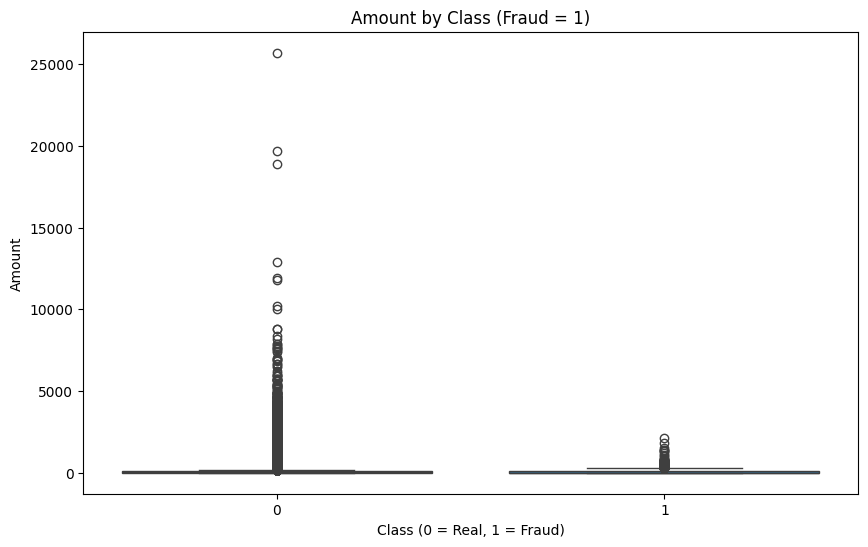

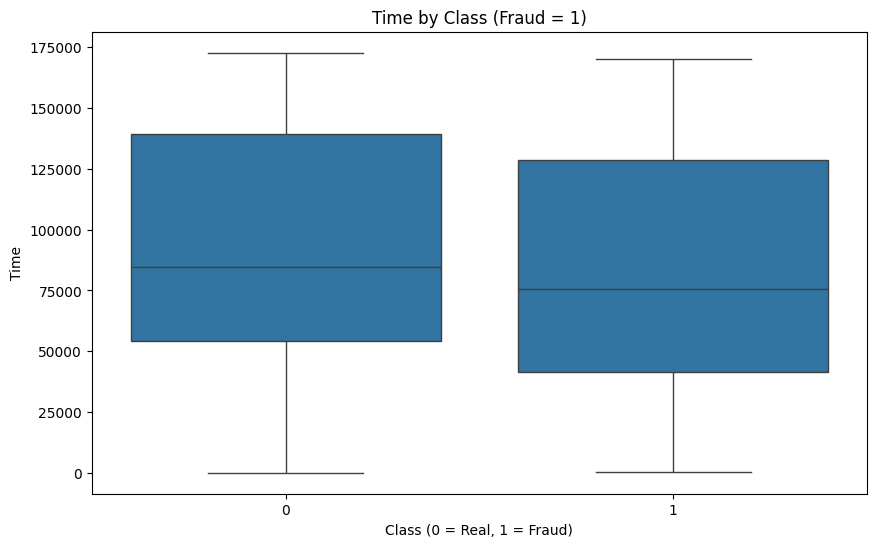

In [15]:
specific = ['Amount', 'Time']

for s in specific:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=boxplot_data, x='Class', y=s)
    plt.title(f'{s} by Class (Fraud = 1)')
    plt.xlabel('Class (0 = Real, 1 = Fraud)')
    plt.ylabel(s)
    plt.show()

## Correlation Analysis

**Full Correlation Heatmap**

Note: Due to the features being PCA components, the vast majority of correlation heat map displays light blue, signifying very little or no correlation between the features.

In [16]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

In [17]:
columns = data.columns

assembler = VectorAssembler(inputCols=columns, outputCol="features")
vector_data = assembler.transform(data).select("features")
corr_matrix = Correlation.corr(vector_data, "features", method="pearson").head()[0]

In [18]:
corr_matrix = corr_matrix.toArray()
corr_matrix = pd.DataFrame(corr_matrix, index=columns, columns=columns)

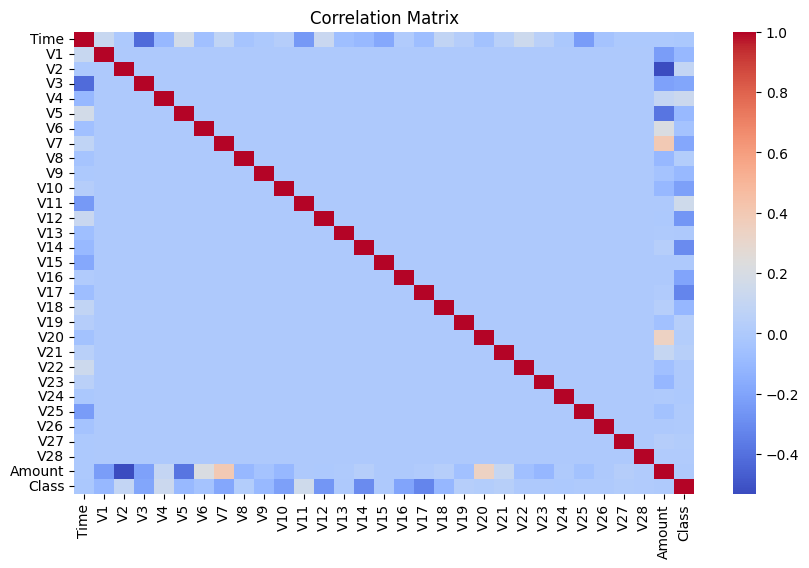

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap( corr_matrix, annot=False, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

**Bar Charts of Correlation with Class**

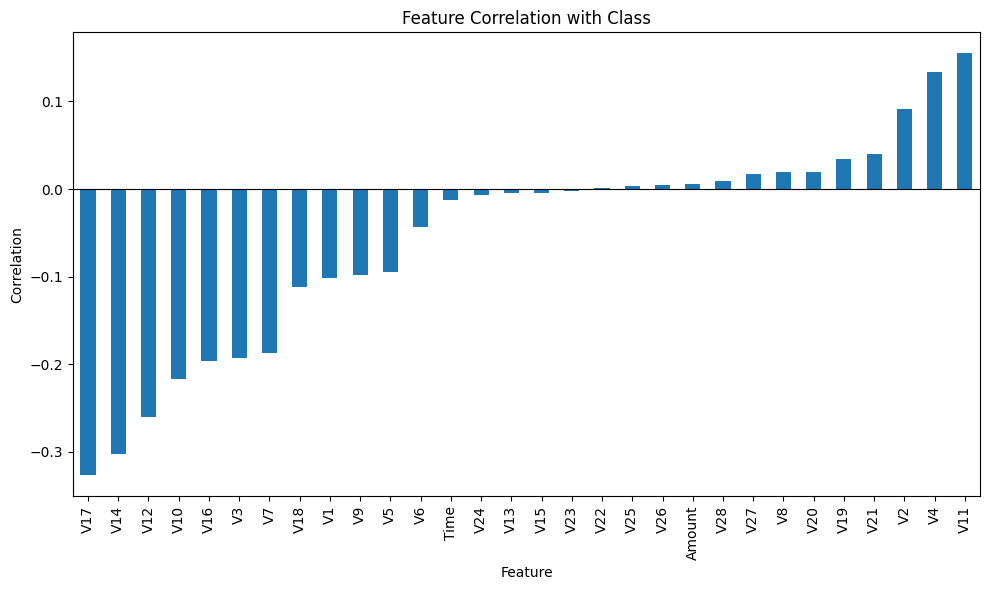

In [20]:
# Correlation of features with Class
corr_with_class = (corr_matrix["Class"].drop("Class").sort_values())

# Plot
plt.figure(figsize=(10, 6))
corr_with_class.plot(kind="bar")
plt.title("Feature Correlation with Class")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Feature")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

**Boxplots for Amount and Time**

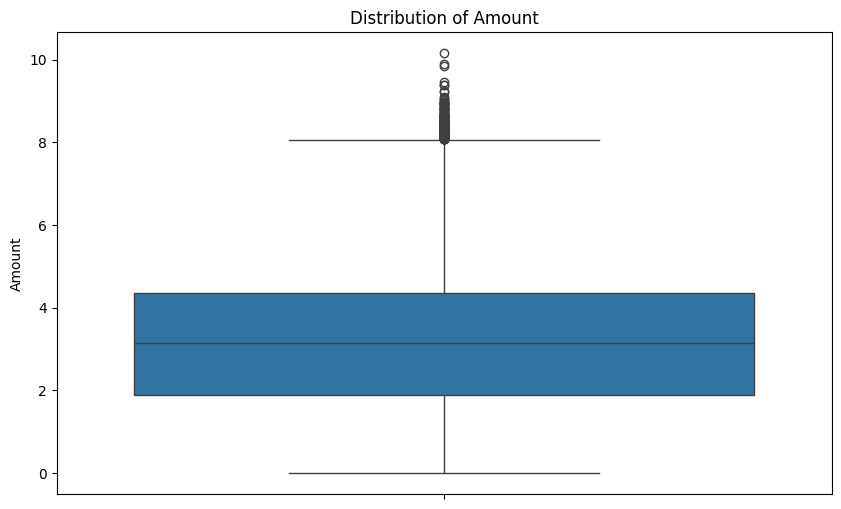

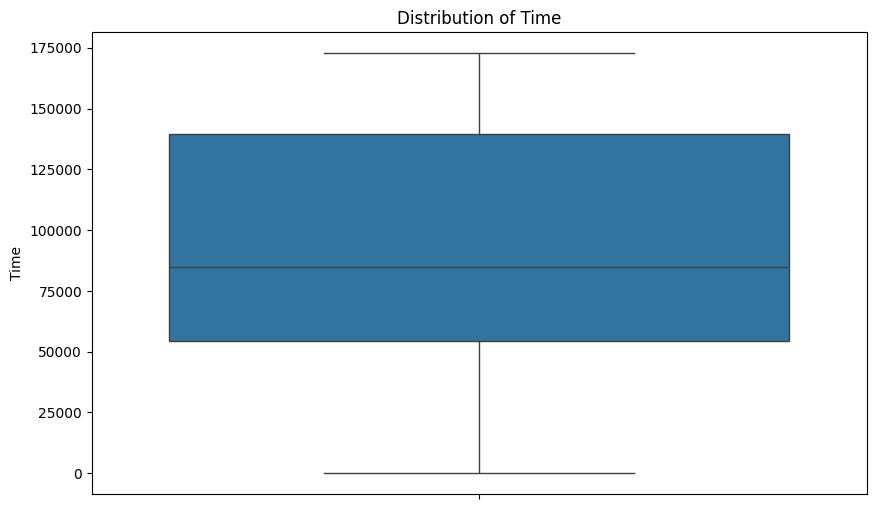

In [21]:
specific = ['Amount', 'Time']

for s in specific:
    if s == 'Amount':
        plt.figure(figsize=(10, 6))
        sns.boxplot(y=np.log1p(boxplot_data['Amount']))
        plt.title(f'Distribution of {s}')
    else:
        plt.figure(figsize=(10, 6))
        sns.boxplot(y=boxplot_data[s])
        plt.title(f'Distribution of {s}')
    plt.show()

## Key Findings & Implications for Modeling

**Class Imbalance**

There is a severe class imbalance in the dataset as demonstrated above. Fraud cases represent only 0.17% of all transactions in this dataset. As a result, modeling will require a technique to address this imbalance. The most appropriate approach in this case is the application of class weights to impose a greater penalty on the misclassification of fraud cases. This is necessary because, without adjustment, a model predicting non-fraud for every transaction would still achieve a near-minimal loss, given that legitimate transactions constitute the overwhelming majority of observations. By weighting fraud misclassifications more heavily, the decision boundary becomes more sensitive to fraud, increasing the likelihood that the model flags uncertain cases as fraudulent and thereby improving recall. Recall is the primary metric of interest here because, in the context of fraud detection, false positives represent minor inconveniences, whereas false negatives carry significant financial and reputational consequences. Accuracy is not a meaningful metric in this context, as a naïve classifier that predicts non-fraud universally would still achieve approximately 99.83% accuracy.

**Feature Inspection**

<u>Time</u>: Although one might reasonably expect that seconds elapsed since the first transaction carries little meaningful signal — being largely an artifact of data collection — EDA revealed a modest but observable difference in the distribution of Time between fraud and non-fraud cases. This suggests the feature may carry some predictive signal, potentially reflecting patterns such as fraud clustering during certain periods. Accordingly, it will be retained for the initial model and reassessed following feature selection.

<u>Weak V Features</u>: Features V13, V15, V22, V23, and V25 exhibited near-zero correlation with the target variable in the correlation analysis, making them reasonable candidates for exclusion.
